In [1]:
import requests
import sys
sys.path.append('sources')
headers = {
	"Content-Type": "application/json",
}
url = "http://127.0.0.1:8001/"

## Read a bundle from the CPI dataset

In [2]:
import random
from experiments.etl.read import read_cpi_bundles

x = 1
y = 1
bundles = read_cpi_bundles(x=x,y=y)
print("Size: ", len(bundles))

w = random.randint(0, len(bundles)-1)
print(f"x={x}, y={y}, w={w}")
bpmn = bundles[w].copy()
metedata = bpmn.pop('metadata')
bpmn

Size:  5400
x=1, y=1, w=2683


{'type': 'choice',
 'id': 0,
 'true': {'type': 'sequence',
  'id': 1,
  'head': {'type': 'task',
   'id': 2,
   'duration': 9,
   'impacts': {'impact_1': 0.060580432191132225,
    'impact_2': 0.0003692845908435105,
    'impact_3': 0.7406709684564268,
    'impact_4': 0.9800749186894185,
    'impact_5': 0.03935993457923811,
    'impact_6': 0.05077779182893279,
    'impact_7': 0.7521021374898578,
    'impact_8': 0.0067875399679927905,
    'impact_9': 7.440934442494273e-05,
    'impact_10': 0.04514578252945165}},
  'tail': {'type': 'task',
   'id': 3,
   'duration': 1,
   'impacts': {'impact_1': 0.0037830547287688943,
    'impact_2': 9.276150369367296e-06,
    'impact_3': 0.25734158468238577,
    'impact_4': 0.773895228873471,
    'impact_5': 0.6089804900097253,
    'impact_6': 0.20865314603657714,
    'impact_7': 0.051705267442205646,
    'impact_8': 0.04962455853418318,
    'impact_9': 0.007857598587884233,
    'impact_10': 0.3057357914885619}}},
 'false': {'type': 'task',
  'id': 4,
  '

### Check BPMN

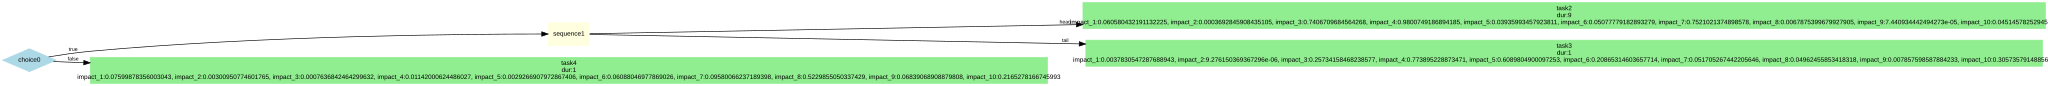

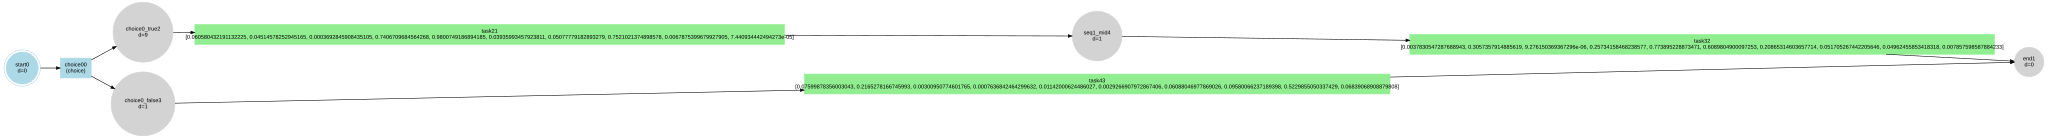

In [3]:
import graphviz
from IPython.display import display, SVG

try:
	resp = requests.get(f'{url}create_spin', json={'cpi_dict': bpmn},  headers=headers)
	resp.raise_for_status()
	response = resp.json()
	display(SVG(graphviz.Source(response['cpi_dot']).pipe(format="svg")))
	display(SVG(graphviz.Source(response['spin_dot']).pipe(format="svg")))
	prism_model = response['prism_model']

except requests.exceptions.HTTPError as e:
	print(f"HTTP Error ({resp.status_code}):", resp.json())

In [4]:
try:
	resp = requests.get(f'{url}run_prism_analysis', json={'cpi_dict': bpmn},  headers=headers)
	resp.raise_for_status()
	response = resp.json()
	print(response)

except requests.exceptions.HTTPError as e:
	print(f"HTTP Error ({resp.status_code}):", resp.json())

HTTP Error (500): {'detail': "Command '['prism', '/app/models/tmp_0f67d76f-253f-4c9a-aa13-879ef17004f0.nm', '-exporttransdotstates', '/app/tmp_0f67d76f-253f-4c9a-aa13-879ef17004f0.dot', '-exportstates', '/app/models/tmp_0f67d76f-253f-4c9a-aa13-879ef17004f0_states.csv', '-exporttrans', '/app/models/tmp_0f67d76f-253f-4c9a-aa13-879ef17004f0_trans.tra', '-verbose']' returned non-zero exit status 1."}
